In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize

all_keywords = sorted({kw for v in result.values() for kw in v["most_associated_keywords"]})
triggers     = list(result.keys())

matrix = pd.DataFrame(
    [[result[t]["most_associated_keywords"].get(kw, 0) for kw in all_keywords] for t in triggers],
    index=triggers,
    columns=all_keywords,
)

# Normalizza per riga (profilo relativo, non assoluto)
matrix_norm = pd.DataFrame(
    normalize(matrix.values, norm="l1"),
    index=triggers,
    columns=all_keywords,
)

print(matrix_norm.shape)
matrix_norm.head()

(16, 151)


,CLAAssistant,ReleaseNotification,add-to-project,agent-protocol-test,analysis,analyze,api-v2-unit-test,auto-assign,auto-fix,autoSyncMergedPullRequest,...,type-check,unit-test,unit-tests,update-cassettes,update-pyproject-and-tags,validate,validate-agents-format,verify-version,version,welcome-message
push,0.0,0.000000,0.0,0.00,0.00,0.050459,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
pull_request,0.0,0.000000,0.0,0.00,0.00,0.064103,0.0,0.0,0.000000,0.0,...,0.019231,0.0,0.019231,0.0,0.0,0.0,0.000000,0.019231,0.0,0.0
workflow_dispatch,0.0,0.000000,0.0,0.00,0.00,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
schedule,0.0,0.000000,0.0,0.02,0.04,0.160000,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
workflow_call,0.0,0.025641,0.0,0.00,0.00,0.000000,0.0,0.0,0.025641,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.025641,0.000000,0.0,0.0


Estriamo i trigger e i relativi job andando a crere una matrice, classifichiamo la similarità dei job se hanno una distribuzione simile di job associati a quel workflow

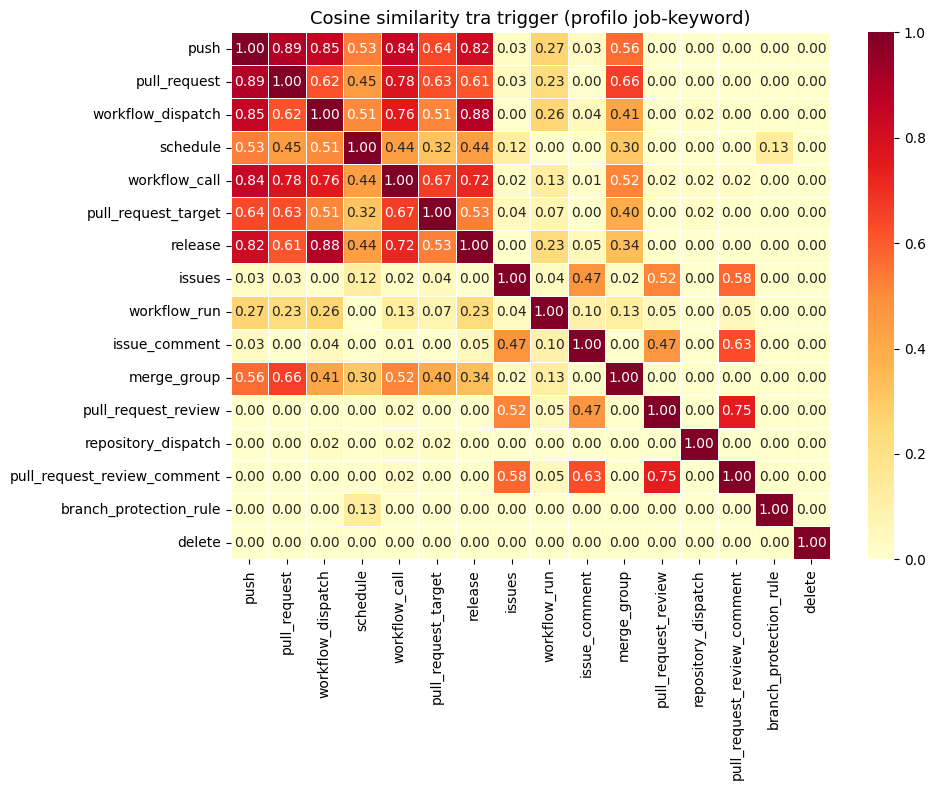

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(matrix_norm)
sim_df = pd.DataFrame(sim, index=triggers, columns=triggers)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    sim_df,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Cosine similarity tra trigger (profilo job-keyword)", fontsize=13)
plt.tight_layout()
plt.savefig("trigger_similarity_heatmap.png", dpi=150)
plt.show()

Clustering


Silhouette per k:
k=2: 0.5031
k=3: 0.5238
k=4: 0.2192
k=5: 0.2363
k=6: 0.1949
k=7: 0.1231
k=8: 0.1031
k=9: 0.1050
k=10: 0.1029

Miglior k (silhouette): 3 con score=0.5238


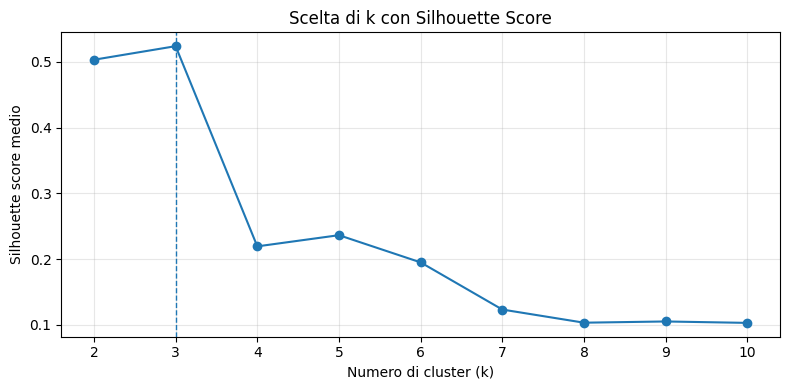

NameError: name 'fcluster' is not defined

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Valuta k possibili e seleziona quello con silhouette media migliore
k_values = list(range(2, min(10, len(triggers)) + 1))
sil_scores = []

for k in k_values:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels_k = model.fit_predict(matrix_norm.values)
    score = silhouette_score(matrix_norm.values, labels_k, metric="euclidean")
    sil_scores.append(score)

best_idx = int(np.argmax(sil_scores))
best_k = k_values[best_idx]
best_score = sil_scores[best_idx]

print("Silhouette per k:")
for k, s in zip(k_values, sil_scores):
    print(f"k={k}: {s:.4f}")

print(f"\nMiglior k (silhouette): {best_k} con score={best_score:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, sil_scores, marker="o")
ax.axvline(best_k, linestyle="--", linewidth=1)
ax.set_title("Scelta di k con Silhouette Score", fontsize=12)
ax.set_xlabel("Numero di cluster (k)")
ax.set_ylabel("Silhouette score medio")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Applica il k migliore al clustering gerarchico già calcolato sopra
labels_best = fcluster(Z, best_k, criterion="maxclust")
cluster_map_best = pd.Series(labels_best, index=triggers).sort_values()
print("\nAssegnazione trigger -> cluster (k ottimale):")
print(cluster_map_best.to_string())

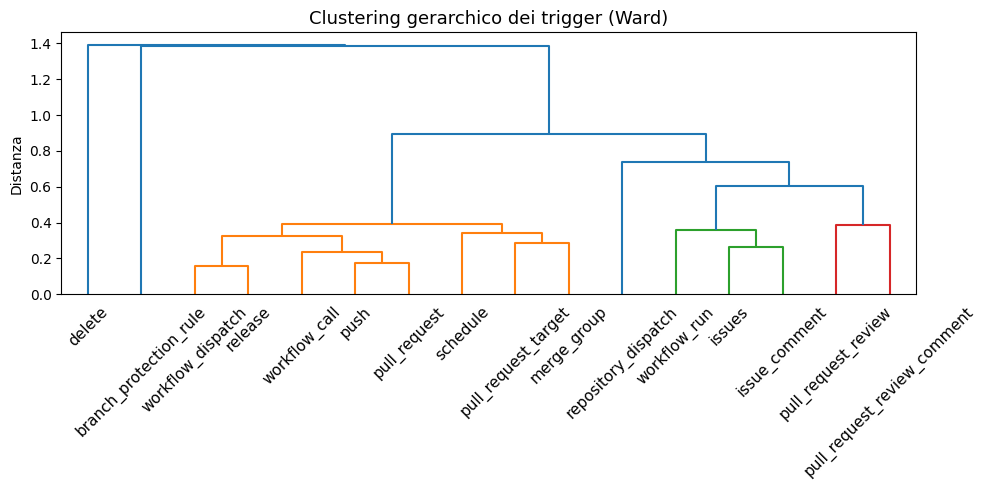

push                           1
pull_request                   1
workflow_dispatch              1
schedule                       1
workflow_call                  1
pull_request_target            1
release                        1
issues                         1
workflow_run                   1
issue_comment                  1
merge_group                    1
pull_request_review            1
repository_dispatch            1
pull_request_review_comment    1
branch_protection_rule         2
delete                         3


In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(matrix_norm, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(Z, labels=triggers, ax=ax, leaf_rotation=45, leaf_font_size=11, color_threshold=0.6)
ax.set_title("Clustering gerarchico dei trigger (Ward)", fontsize=13)
ax.set_ylabel("Distanza")
plt.tight_layout()
plt.savefig("trigger_dendrogram.png", dpi=150)
plt.show()

k = 3
labels = fcluster(Z, k, criterion="maxclust")
cluster_map = pd.Series(labels, index=triggers).sort_values()
print(cluster_map.to_string())

In [ ]:
AI_KEYWORDS = {"claude", "auto-fix", "autopr", "run-agent", "trigger-devin",
               "claude-review", "dogfood", "validate-agents-format"}

cluster_map_df = cluster_map.reset_index()
cluster_map_df.columns = ["trigger", "cluster"]

for c in sorted(cluster_map_df["cluster"].unique()):
    members = cluster_map_df.loc[cluster_map_df["cluster"] == c, "trigger"].tolist()
    
    # Somma i profili grezzi del cluster
    profile = matrix.loc[members].sum().sort_values(ascending=False)
    top_kw  = profile.head(8)
    ai_kw   = {kw: int(profile[kw]) for kw in AI_KEYWORDS if kw in profile and profile[kw] > 0}
    
    print(f"\n{'─'*55}")
    print(f"  Cluster {c}: {members}")
    print(f"  Top keyword: {dict(top_kw)}")
    if ai_kw:
        print(f"  ⚡ AI-native signals: {ai_kw}")
    else:
        print(f"  (nessun keyword AI-native)")


───────────────────────────────────────────────────────
  Cluster 1: ['push', 'pull_request', 'workflow_dispatch', 'schedule', 'workflow_call', 'pull_request_target', 'release', 'issues', 'workflow_run', 'issue_comment', 'merge_group', 'pull_request_review', 'repository_dispatch', 'pull_request_review_comment']
  Top keyword: {'build': np.int64(172), 'test': np.int64(95), 'deploy': np.int64(53), 'lint': np.int64(48), 'release': np.int64(32), 'publish': np.int64(31), 'analyze': np.int64(31), 'claude': np.int64(12)}
  ⚡ AI-native signals: {'autopr': 2, 'dogfood': 1, 'claude': 12, 'claude-review': 3, 'trigger-devin': 1, 'validate-agents-format': 1, 'run-agent': 2, 'auto-fix': 6}

───────────────────────────────────────────────────────
  Cluster 2: ['branch_protection_rule']
  Top keyword: {'analysis': np.int64(2), 'CLAAssistant': np.int64(0), 'permissions': np.int64(0), 'merge_docker_manifest': np.int64(0), 'migrate': np.int64(0), 'mypy': np.int64(0), 'notify': np.int64(0), 'open': np.in